# chuq_split — posterior-predictive credible intervals & empirical coverage

For **both** models (low = surface-only, high = volume-only) on **all** datasets in **all three**
energy bands (low / test / high). The posterior predictive at each data point is the mixture over
posterior samples of $\mathcal{N}(y_{\rm model}(\theta),\ \sigma^2_{\rm stat} + (e^{\gamma} y_{\rm
model})^2)$ — the same noise model as the fit likelihood (statistical + fractional model error).

Empirical coverage uses the **PIT** (probability integral transform): $p_i = \mathrm{CDF}_{\rm
pred}(y_i)$ evaluated exactly via the normal-mixture CDF. A point sits inside the central
$\alpha$-credible interval iff $|p_i - \tfrac12| \le \alpha/2$, so no interval-sampling noise enters
the coverage curves. Calibrated $\Rightarrow$ empirical = nominal (the diagonal).

Band roles differ per model: each model **trains** on its own band, the `test` band is **held out
from both**, and the opposite extreme band is a pure **extrapolation**.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

import chuq_io
import chuq_model

chuq_io.use_paper_style()

fit_info = chuq_io.load_fit_info()
e_split_low, e_split_high = fit_info["E0"], fit_info["E1"]

posterior_samples = chuq_io.load_all_posteriors()
datasets = chuq_io.load_datasets()
models_by_variant = {v: chuq_model.build_model(v) for v in chuq_io.VARIANT_NAMES}

band_counts = {
    band: sum(
        chuq_io.band_of(d, e_split_low, e_split_high) == band for d in datasets
    )
    for band in chuq_io.BAND_NAMES
}
print(f"{len(datasets)} datasets:", band_counts)

Using database version X4-2025-12-31 located in: /mnt/home/beyerkyl/x4db/unpack_exfor-2025/X4-2025-12-31
51 datasets: {'low': 25, 'test': 13, 'high': 13}


## Predictive computation

One record per (model, dataset): per-point PITs (exact mixture CDF at the datum) and predictive
band quantiles (2.5 / 16 / 50 / 84 / 97.5 %) from noise-sampled predictive draws.

In [2]:
# --- settings ------------------------------------------------------------------------------
N_PREDICTIVE_DRAWS = 300  # posterior draws per variant
PREDICTIVE_SEED = 3
BAND_QUANTILES = [2.5, 16, 50, 84, 97.5]
Q025, Q16, Q50, Q84, Q975 = range(5)  # index names for the rows of "pred_quantiles"

rng = np.random.default_rng(PREDICTIVE_SEED)
draws_by_variant = {
    v: posterior_samples[v][
        rng.choice(len(posterior_samples[v]), N_PREDICTIVE_DRAWS, replace=False)
    ]
    for v in chuq_io.VARIANT_NAMES
}

predictive_records = []
for variant in chuq_io.VARIANT_NAMES:
    n_free = chuq_model.n_omp(variant)
    theta_omp = draws_by_variant[variant][:, :n_free]
    # column vector so it broadcasts against the (n_draws, n_points) prediction array
    model_err_frac = np.exp(draws_by_variant[variant][:, n_free])[:, None]

    for dataset in datasets:
        y_pred = np.array(
            [
                np.asarray(models_by_variant[variant](dataset, *theta))
                for theta in theta_omp
            ]
        )  # (n_draws, n_points)

        # Two predictive widths, to separate the two sources of uncertainty:
        #   sigma_total     = statistical noise + fitted model discrepancy (what the fit used)
        #   sigma_stat_only = statistical noise alone (what the model would claim on its own)
        # The gap between the coverage curves they produce is the work the discrepancy term does.
        sigma_total = np.sqrt(
            chuq_io.predictive_variance(dataset, y_pred, model_err_frac)
        )
        sigma_stat_only = np.sqrt(
            np.broadcast_to(chuq_io.statistical_variance(dataset), y_pred.shape)
        )

        y_data = np.asarray(dataset.y)[None, :]
        # PIT = predictive CDF evaluated AT THE DATUM. Orientation matters: (y_data - y_pred)
        # puts the datum in the numerator, so pit -> 0 when the datum sits far below the
        # prediction and -> 1 far above. Averaging the per-sample normal CDFs over draws is the
        # exact CDF of the normal *mixture*, so no interval-sampling noise enters the coverage
        # curves at all.
        pit_full = norm.cdf((y_data - y_pred) / sigma_total).mean(0)
        pit_stat_only = norm.cdf((y_data - y_pred) / sigma_stat_only).mean(0)

        # Sampled draws are used ONLY for the plotted bands below; coverage uses the exact PITs
        # above. The two estimators agree in the limit of many draws but need not at N=300.
        noisy_draws = y_pred + sigma_total * rng.standard_normal(y_pred.shape)

        predictive_records.append(
            dict(
                model=variant,
                band=chuq_io.band_of(dataset, e_split_low, e_split_high),
                e_lab=chuq_io.elab(dataset),
                dataset=dataset,
                pit_full=pit_full,
                pit_stat_only=pit_stat_only,
                pred_quantiles=np.percentile(noisy_draws, BAND_QUANTILES, axis=0),
            )
        )

print(
    f"{len(predictive_records)} (model, dataset) records x "
    f"{N_PREDICTIVE_DRAWS} predictive draws"
)

102 (model, dataset) records x 300 predictive draws


## Empirical coverage curves — per band, both models

Empirical fraction of data points inside the central $\alpha$-interval vs nominal $\alpha$. Above
the diagonal = predictive too wide (conservative), below = too narrow (overconfident). **Solid** =
full predictive (statistical + $e^{\gamma}$ model discrepancy); **dashed**, same color = model-only
predictive (statistical noise only) — the gap between them is the work the discrepancy term does.

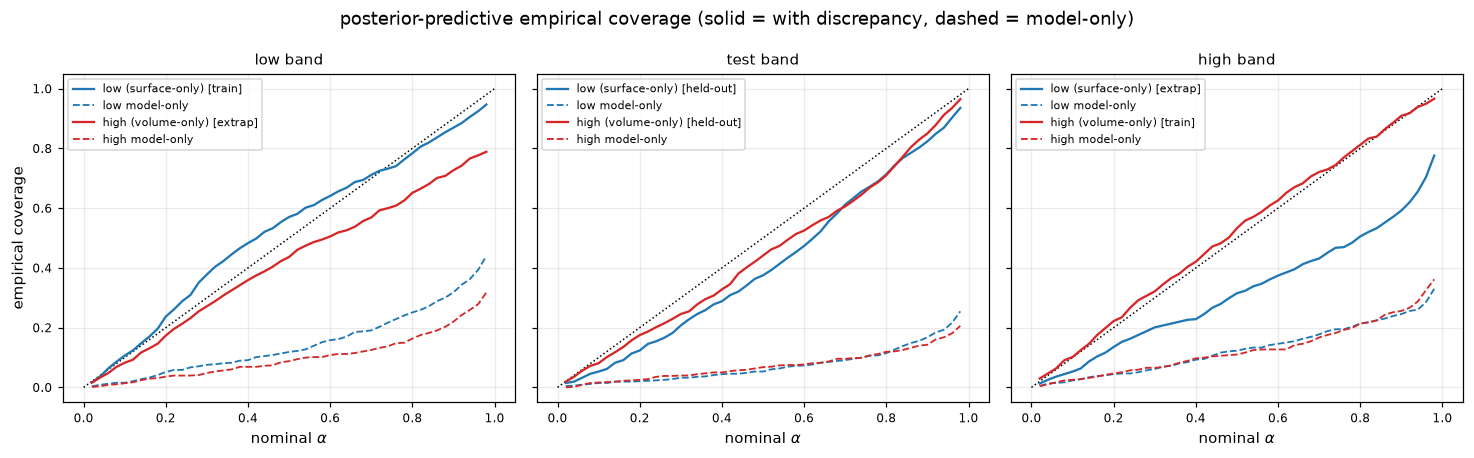

,band,model,role,n_pts,cov68,cov90,cov95,cov68_model_only,cov95_model_only
0,low,low,train,582,0.694,0.869,0.918,0.187,0.376
1,low,high,extrap,582,0.557,0.727,0.770,0.120,0.268
2,test,low,held-out,680,0.582,0.824,0.885,0.088,0.201
3,test,high,held-out,680,0.591,0.850,0.919,0.096,0.174
4,high,low,extrap,473,0.423,0.592,0.679,0.169,0.279
5,high,high,train,473,0.706,0.909,0.943,0.154,0.300


In [3]:
NOMINAL_LEVELS = np.linspace(0.02, 0.98, 49)


def gather_pits(variant, band, key):
    """All per-point PITs for one (model, band), concatenated across datasets."""
    return np.concatenate(
        [
            r[key]
            for r in predictive_records
            if r["model"] == variant and r["band"] == band
        ]
    )


def empirical_coverage(pit_values, alpha):
    """Fraction of points inside the central alpha-credible interval.

    A point lies inside the central alpha interval exactly when its PIT lies in
    [(1-alpha)/2, (1+alpha)/2], i.e. when |PIT - 1/2| <= alpha/2. That identity is what lets
    coverage be read straight off the PITs with no interval construction.
    """
    return float(np.mean(np.abs(pit_values - 0.5) <= alpha / 2))


coverage_rows = []
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), sharey=True)
for ax, band in zip(axes, chuq_io.BAND_NAMES):
    ax.plot([0, 1], [0, 1], "k:", lw=1)  # perfect calibration
    for variant in chuq_io.VARIANT_NAMES:
        pit_full = gather_pits(variant, band, "pit_full")
        pit_stat_only = gather_pits(variant, band, "pit_stat_only")
        role = chuq_io.band_role(variant, band)
        ax.plot(
            NOMINAL_LEVELS,
            [empirical_coverage(pit_full, a) for a in NOMINAL_LEVELS],
            color=chuq_io.VARIANT_COLOR[variant],
            label=f"{variant} ({chuq_io.VARIANT_FORM[variant]}) [{role}]",
        )
        ax.plot(
            NOMINAL_LEVELS,
            [empirical_coverage(pit_stat_only, a) for a in NOMINAL_LEVELS],
            color=chuq_io.VARIANT_COLOR[variant],
            ls="--",
            lw=1.2,
            label=f"{variant} model-only",
        )
        coverage_rows.append(
            dict(
                band=band,
                model=variant,
                role=role,
                n_pts=pit_full.size,
                cov68=empirical_coverage(pit_full, 0.68),
                cov90=empirical_coverage(pit_full, 0.90),
                cov95=empirical_coverage(pit_full, 0.95),
                cov68_model_only=empirical_coverage(pit_stat_only, 0.68),
                cov95_model_only=empirical_coverage(pit_stat_only, 0.95),
            )
        )
    ax.set_title(f"{band} band")
    ax.set_xlabel(r"nominal $\alpha$")
    ax.legend(fontsize=7)

axes[0].set_ylabel("empirical coverage")
fig.suptitle(
    "posterior-predictive empirical coverage "
    "(solid = with discrepancy, dashed = model-only)"
)
fig.tight_layout()
chuq_io.save_figure(fig, "coverage_curves")
plt.show()

coverage_table = pd.DataFrame(coverage_rows)
display(coverage_table.round(3))

## Per-dataset coverage vs energy

68% and 95% per-dataset empirical coverage vs $E_{lab}$ (shaded band = held-out test region).
Filled markers + dashed connecting line in a lighter tone = **model-only** predictive; filled
markers + solid line = full predictive with discrepancy. Datasets are small (10–60 pts), so scatter
is expected; systematic runs of low coverage mark energies where a predictive is overconfident.

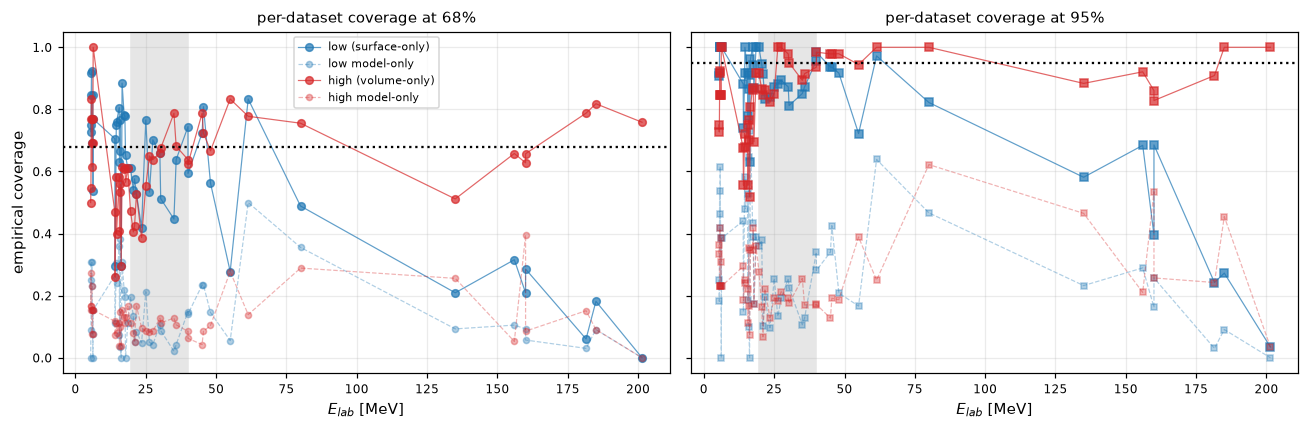

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (level, marker) in zip(axes, ((0.68, "o"), (0.95, "s"))):
    for variant in chuq_io.VARIANT_NAMES:
        records_sorted = sorted(
            (r for r in predictive_records if r["model"] == variant),
            key=lambda r: r["e_lab"],
        )
        energies = [r["e_lab"] for r in records_sorted]
        ax.plot(
            energies,
            [empirical_coverage(r["pit_full"], level) for r in records_sorted],
            marker,
            ls="-",
            lw=0.8,
            color=chuq_io.VARIANT_COLOR[variant],
            alpha=0.7,
            ms=5,
            label=f"{variant} ({chuq_io.VARIANT_FORM[variant]})",
        )
        ax.plot(
            energies,
            [empirical_coverage(r["pit_stat_only"], level) for r in records_sorted],
            marker,
            ls="--",
            lw=0.8,
            color=chuq_io.VARIANT_COLOR[variant],
            alpha=0.35,
            ms=4,
            label=f"{variant} model-only",
        )
    ax.axhline(level, color="k", ls=":")
    ax.axvspan(e_split_low, e_split_high, color="0.9", zorder=0)  # held-out band
    ax.set_title(f"per-dataset coverage at {level:.0%}")
    ax.set_xlabel(r"$E_{lab}$ [MeV]")

axes[0].set_ylabel("empirical coverage")
axes[0].legend(fontsize=7)
fig.tight_layout()
chuq_io.save_figure(fig, "coverage_vs_energy")
plt.show()

## Predictive credible intervals on every dataset

Dark band = 68%, light band = 95% central posterior-predictive interval; both models overlaid on
each dataset, grouped by energy band.

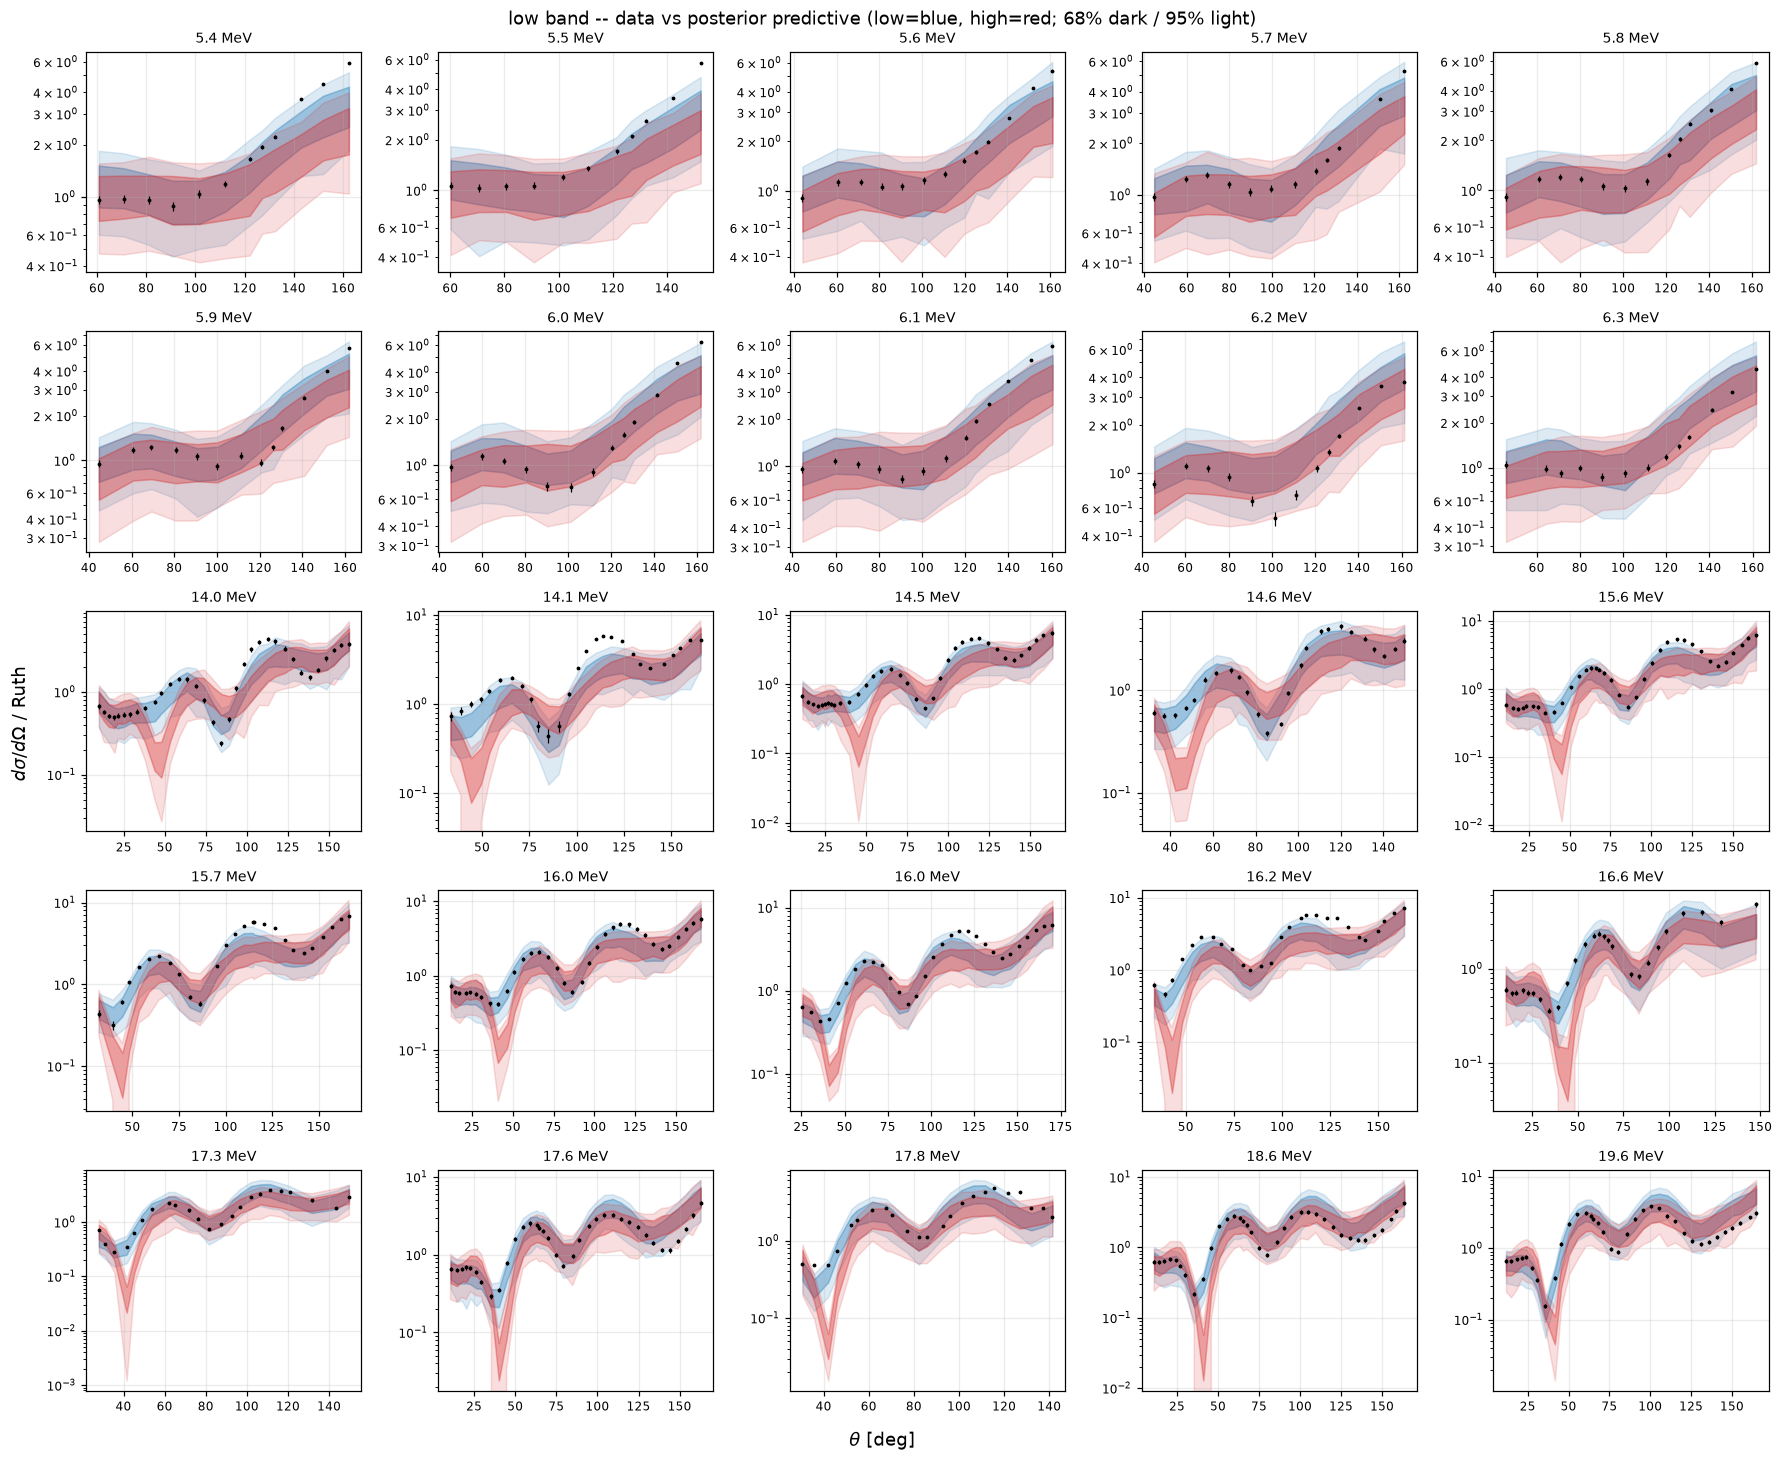

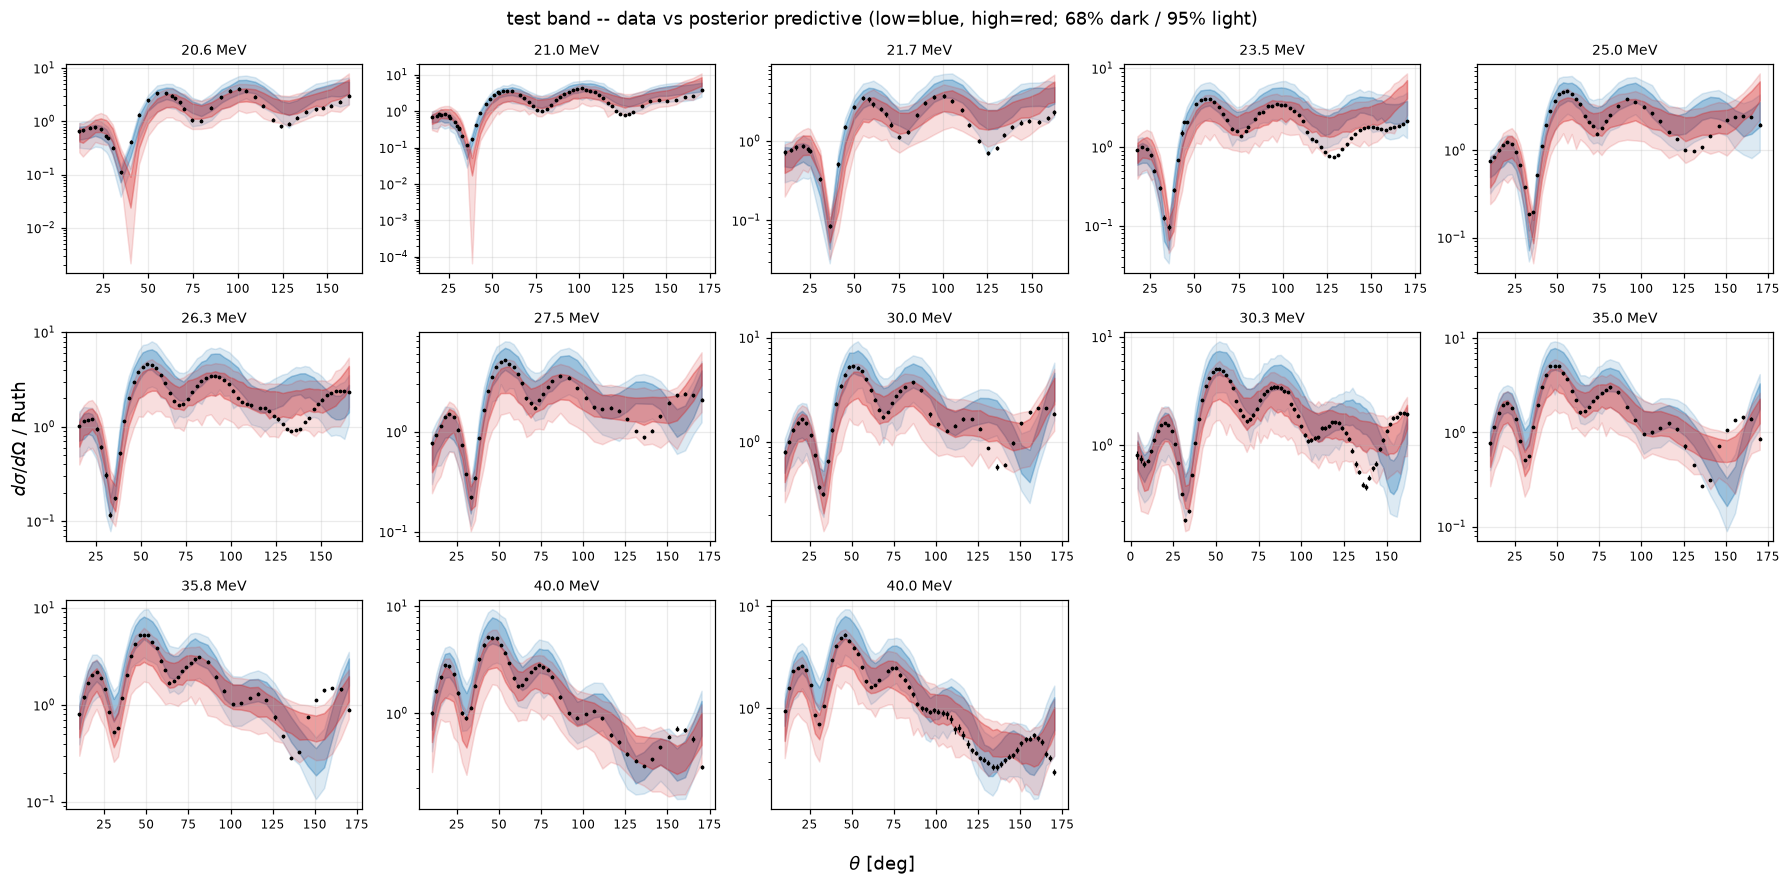

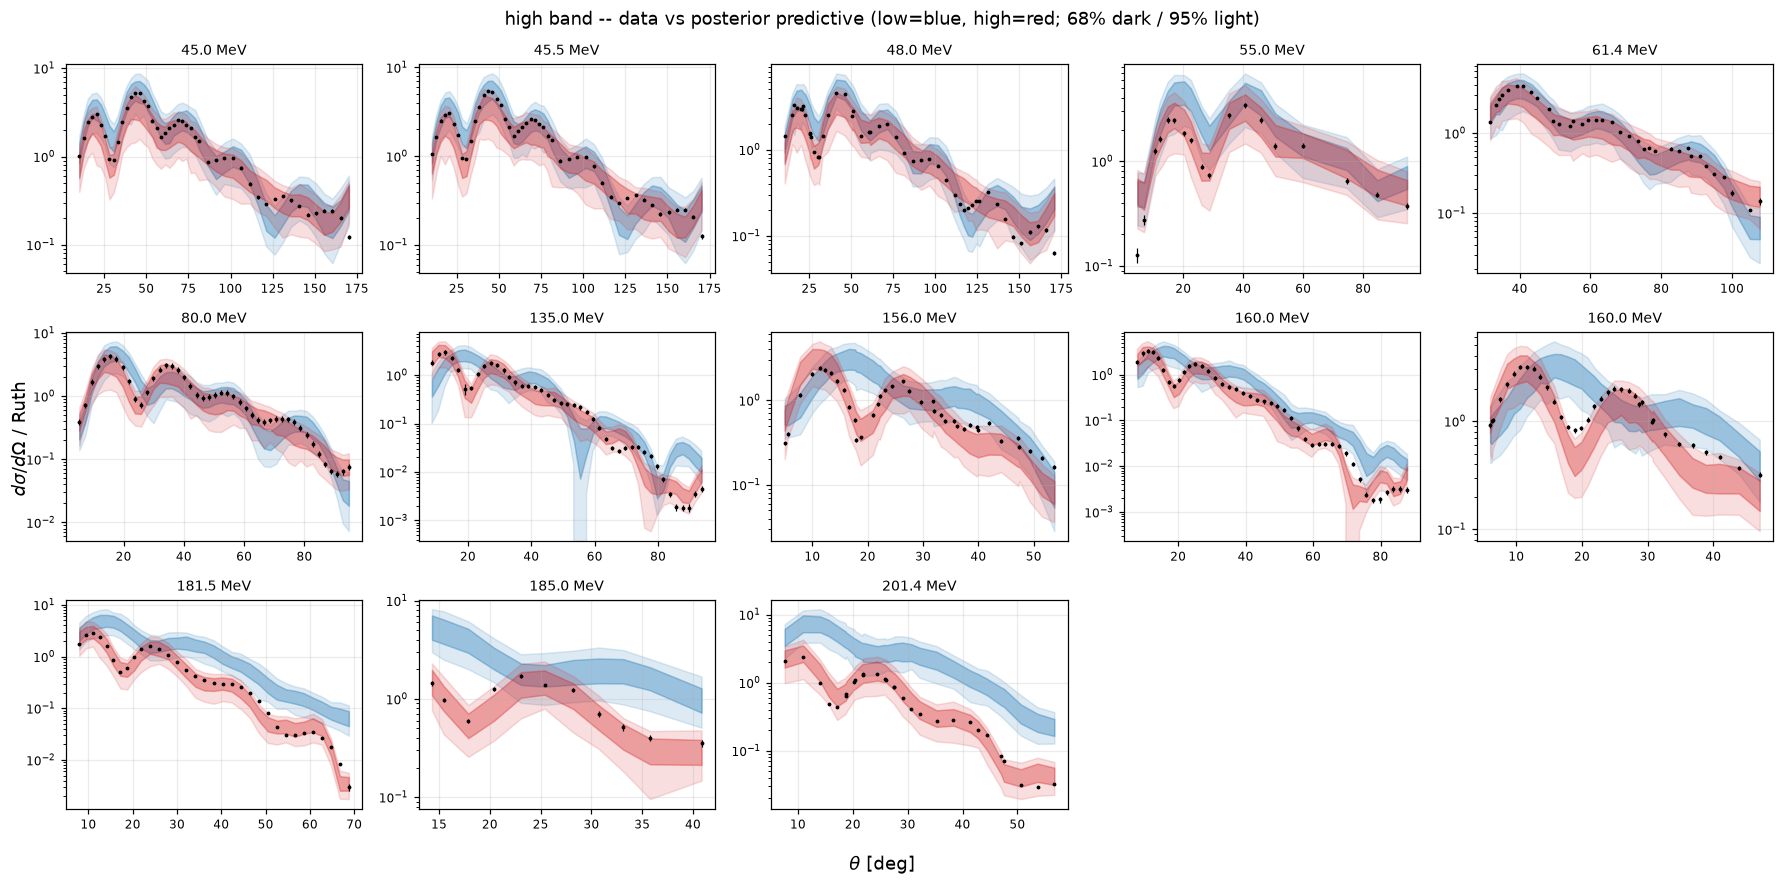

In [5]:
N_GRID_COLS = 5

# Every dataset produced one record per variant. Index them so both variants' bands can be
# drawn on the same axes, keyed by the dataset object itself (records hold the object, so
# identity is stable within this notebook run).
record_by_model_and_dataset = {
    (r["model"], id(r["dataset"])): r for r in predictive_records
}

for band in chuq_io.BAND_NAMES:
    # Filter on a single variant purely to enumerate each dataset once -- the dataset list is
    # the same for both, and the loop below draws both variants on each panel.
    band_records = sorted(
        (
            r
            for r in predictive_records
            if r["model"] == chuq_io.VARIANT_NAMES[0] and r["band"] == band
        ),
        key=lambda r: r["e_lab"],
    )
    n_rows = int(np.ceil(len(band_records) / N_GRID_COLS))
    fig, axes = plt.subplots(
        n_rows,
        N_GRID_COLS,
        figsize=(3.3 * N_GRID_COLS, 2.7 * n_rows),
        squeeze=False,
    )
    for ax, record in zip(axes.ravel(), band_records):
        dataset = record["dataset"]
        order = chuq_io.plot_dataset(ax, dataset, label=None, ms=3, lw=0.8, zorder=5)
        theta_deg = np.rad2deg(np.asarray(dataset.x))
        for variant in chuq_io.VARIANT_NAMES:
            quantiles = record_by_model_and_dataset[(variant, id(dataset))][
                "pred_quantiles"
            ]
            ax.fill_between(  # 95% central
                theta_deg[order],
                quantiles[Q025][order],
                quantiles[Q975][order],
                color=chuq_io.VARIANT_COLOR[variant],
                alpha=0.15,
            )
            ax.fill_between(  # 68% central
                theta_deg[order],
                quantiles[Q16][order],
                quantiles[Q84][order],
                color=chuq_io.VARIANT_COLOR[variant],
                alpha=0.35,
            )
        ax.set_title(f"{record['e_lab']:.1f} MeV", fontsize=9)
    for ax in axes.ravel()[len(band_records):]:
        ax.set_visible(False)

    fig.suptitle(
        f"{band} band -- data vs posterior predictive "
        "(low=blue, high=red; 68% dark / 95% light)"
    )
    fig.supxlabel(r"$\theta$ [deg]")
    fig.supylabel(r"$d\sigma/d\Omega\ /\ $Ruth")
    fig.tight_layout()
    chuq_io.save_figure(fig, f"predictive_intervals_{band}_band")
    plt.show()